## Exercice 2

Vous travaillez sur la classification de critiques de films. Chaque critique doit etre transformee en vecteur numerique pour alimenter des modeles ML.

Etapes :

1. CountVectorizer (Bag of Words)
2. Analyse du vocabulaire
3. TfidfVectorizer
4. Densite et sparsité
5. Influence de la normalisation
6. Pipeline complet avec LogisticRegression


In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from nltk.corpus import stopwords
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

critiques = [
    "Ce film est absolument fantastique! La cinematographie est magnifique.",
    "Quel ennui... le scenario est previsible et les acteurs sans charisme.",
    "Un excellent film! Tres emouvant et bien realise. A voir!",
    "Decevant. Les effets speciaux sont bons mais l'histoire manque de profondeur.",
    "Masterpiece! Un incontournable. Brillant du debut a la fin.",
    "Horrible film. Perte de temps totale. Pas recommande."
]

labels = [1, 0, 1, 0, 1, 0]

french_stopwords = stopwords.words("french")

In [ ]:
# Tache 1 : CountVectorizer

count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100
)

X_count = count_vectorizer.fit_transform(critiques)

print("forme de la matrice :", X_count.shape)
print("features :")
print(count_vectorizer.get_feature_names_out())
print()
print("matrice Bag of Words :")
print(X_count.toarray())

Forme de la matrice : (6, 35)
Features :
['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinematographie' 'debut' 'decevant' 'effets' 'emouvant' 'ennui'
 'excellent' 'fantastique' 'film' 'fin' 'histoire' 'horrible'
 'incontournable' 'magnifique' 'manque' 'masterpiece' 'perte' 'previsible'
 'profondeur' 'quel' 'realise' 'recommande' 'sans' 'scenario' 'speciaux'
 'temps' 'totale' 'tres' 'voir']

Matrice Bag of Words :
[[1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1]
 [0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0]]


In [3]:
# Tache 2 : Analyse du vocabulaire

mots = count_vectorizer.get_feature_names_out()
frequences = X_count.toarray().sum(axis=0)

df_vocabulaire = pd.DataFrame({
    "terme": mots,
    "frequence": frequences
}).sort_values(by="frequence", ascending=False)

top_10 = df_vocabulaire.head(10)
print(top_10)

print()
print("Analyse :")
print("Les termes les plus frequents peuvent aider a la classification,")
print("mais certains mots tres generaux sont moins discriminants que des mots")
print("comme horrible, excellent, fantastique ou decevant.")

         terme  frequence
14        film          3
1      acteurs          1
0   absolument          1
2         bien          1
3         bons          1
5     charisme          1
4     brillant          1
7        debut          1
8     decevant          1
9       effets          1

Analyse :
Les termes les plus frequents peuvent aider a la classification,
mais certains mots tres generaux sont moins discriminants que des mots
comme horrible, excellent, fantastique ou decevant.


In [8]:
# Tache 3 : TF-IDF

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100
)

X_tfidf = tfidf_vectorizer.fit_transform(critiques)

print("Forme matrice TF-IDF :", X_tfidf.shape)
print()
print("Matrice TF-IDF :")
print(X_tfidf.toarray())

print()
print("Comparaison BoW vs TF-IDF sur les 5 premiers documents :")
print("Bag of Words :")
print(X_count.toarray()[:5])
print()
print("TF-IDF :")
print(X_tfidf.toarray()[:5])

print()
print("TF-IDF donne plus de poids aux termes discriminants")
print("et reduit l'importance des mots trop frequents dans plusieurs documents.")

Forme matrice TF-IDF : (6, 35)

Matrice TF-IDF :
[[0.47249269 0.         0.         0.         0.         0.
  0.47249269 0.         0.         0.         0.         0.
  0.         0.47249269 0.32711256 0.         0.         0.
  0.         0.47249269 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.37796447 0.         0.         0.         0.37796447
  0.         0.         0.         0.         0.         0.37796447
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.37796447
  0.         0.37796447 0.         0.         0.37796447 0.37796447
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.39285843 0.         0.         0.
  0.         0.         0.         0.         0.39285843 0.
  0.39285843 0.         0.27198077 0.         0.         0.
  0.         0.        

Pourcentage non nul BoW : 17.62 %
Pourcentage non nul TF-IDF : 17.62 %

Memoire BoW dense : 1680 octets
Memoire BoW sparse : 472 octets
Memoire TF-IDF dense : 1680 octets
Memoire TF-IDF sparse : 472 octets


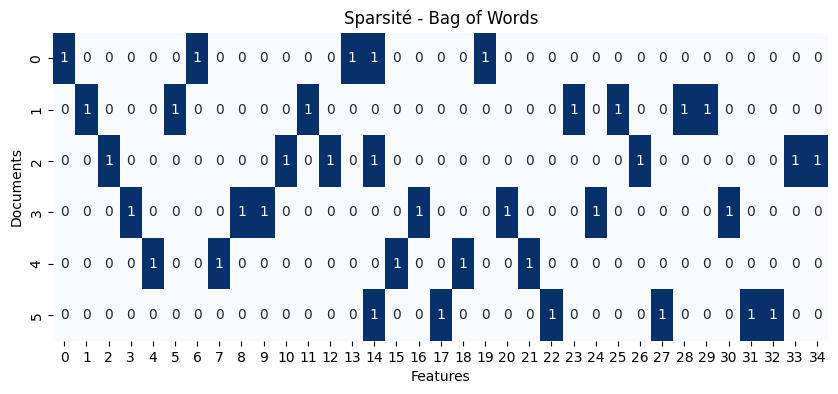

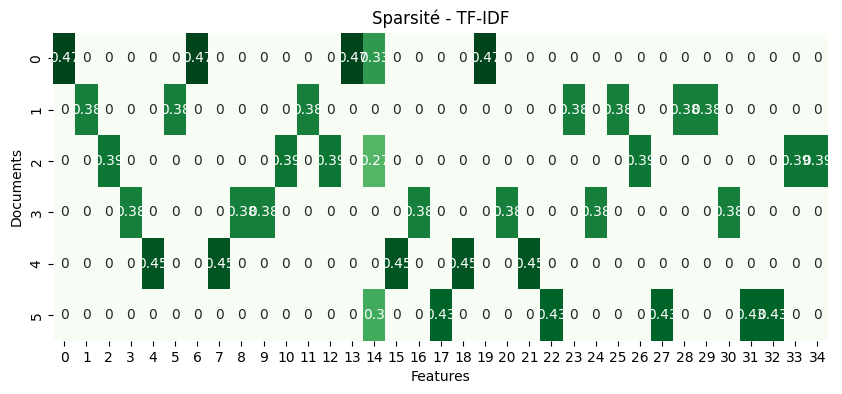

Pour un corpus massif, on utilise une matrice sparse
car elle consomme beaucoup moins de memoire.


In [ ]:
# Tache 4 : Densite et sparsité

densite_count = (X_count.toarray() != 0).sum() / X_count.toarray().size * 100
densite_tfidf = (X_tfidf.toarray() != 0).sum() / X_tfidf.toarray().size * 100

memoire_dense_count = X_count.toarray().nbytes
memoire_sparse_count = X_count.data.nbytes + X_count.indptr.nbytes + X_count.indices.nbytes

memoire_dense_tfidf = X_tfidf.toarray().nbytes
memoire_sparse_tfidf = X_tfidf.data.nbytes + X_tfidf.indptr.nbytes + X_tfidf.indices.nbytes

print("pourcentage non nul BoW :", round(densite_count, 2), "%")
print("pourcentage non nul TF-IDF :", round(densite_tfidf, 2), "%")
print()
print("memoire BoW dense :", memoire_dense_count, "octets")
print("memoire BoW sparse :", memoire_sparse_count, "octets")
print("memoire TF-IDF dense :", memoire_dense_tfidf, "octets")
print("memoire TF-IDF sparse :", memoire_sparse_tfidf, "octets")

plt.figure(figsize=(10, 4))
sns.heatmap(X_count.toarray(), annot=True, cmap="Blues", cbar=False)
plt.title("sparsité - Bag of Words")
plt.xlabel("features")
plt.ylabel("documents")
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(X_tfidf.toarray(), annot=True, cmap="Greens", cbar=False)
plt.title("sparsité - TF-IDF")
plt.xlabel("features")
plt.ylabel("documents")
plt.show()

print("pour un corpus massif, on utilise une matrice sparse")
print("car elle consomme beaucoup moins de memoire.")

TF-IDF avec norme L1 :
[[0.21311454 0.         0.         0.         0.         0.
  0.21311454 0.         0.         0.         0.         0.
  0.         0.21311454 0.14754184 0.         0.         0.
  0.         0.21311454 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.14285714 0.         0.         0.         0.14285714
  0.         0.         0.         0.         0.         0.14285714
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.14285714
  0.         0.14285714 0.         0.         0.14285714 0.14285714
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.14942518 0.         0.         0.
  0.         0.         0.         0.         0.14942518 0.
  0.14942518 0.         0.10344891 0.         0.         0.
  0.         0.         0.         0.         0. 

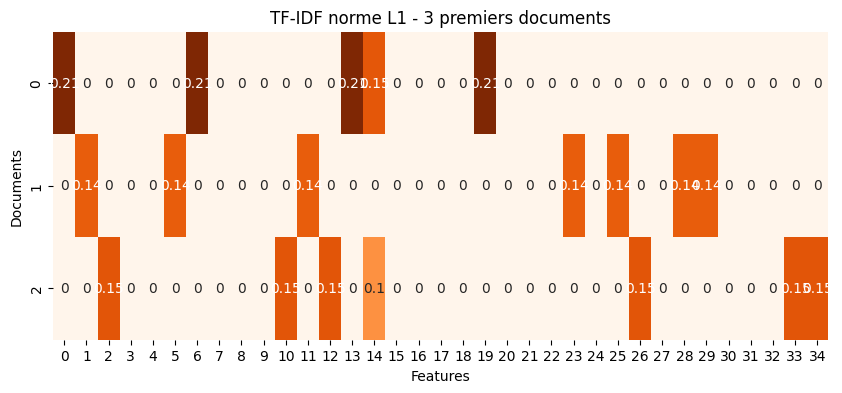

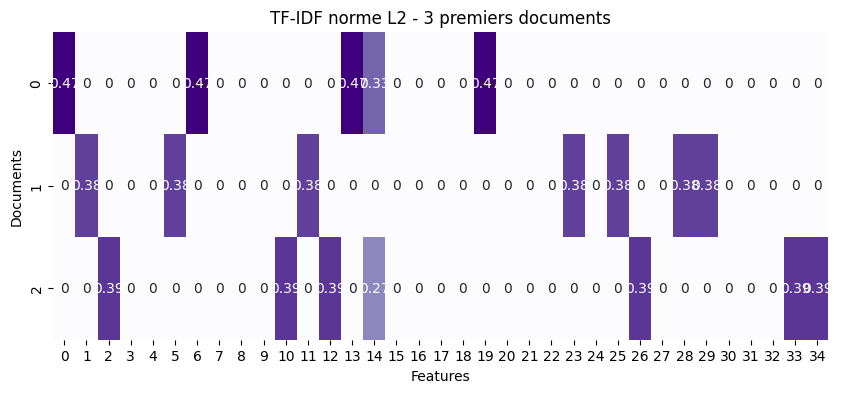

La norme L2 est souvent la plus utilisee
car elle est adaptee a beaucoup de modeles de machine learning.


In [6]:
# Tache 5 : Influence de la normalisation

tfidf_l1 = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100,
    norm="l1"
)

tfidf_l2 = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100,
    norm="l2"
)

X_l1 = tfidf_l1.fit_transform(critiques)
X_l2 = tfidf_l2.fit_transform(critiques)

print("TF-IDF avec norme L1 :")
print(X_l1.toarray()[:3])

print()
print("TF-IDF avec norme L2 :")
print(X_l2.toarray()[:3])

plt.figure(figsize=(10, 4))
sns.heatmap(X_l1.toarray()[:3], annot=True, cmap="Oranges", cbar=False)
plt.title("TF-IDF norme L1 - 3 premiers documents")
plt.xlabel("Features")
plt.ylabel("Documents")
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(X_l2.toarray()[:3], annot=True, cmap="Purples", cbar=False)
plt.title("TF-IDF norme L2 - 3 premiers documents")
plt.xlabel("Features")
plt.ylabel("Documents")
plt.show()

print("La norme L2 est souvent la plus utilisee")
print("car elle est adaptee a beaucoup de modeles de machine learning.")

In [7]:
# Tache 6 : Pipeline complet

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

critiques_clean = [clean_text(texte) for texte in critiques]

vectorizer_final = TfidfVectorizer(
    stop_words=french_stopwords,
    max_features=100
)

X = vectorizer_final.fit_transform(critiques_clean)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

modele = LogisticRegression()
modele.fit(X_train, y_train)

y_pred = modele.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)

nouveaux_textes = [
    "Un film magnifique et tres emouvant",
    "Scenario horrible et vraiment ennuyeux"
]

nouveaux_textes_clean = [clean_text(texte) for texte in nouveaux_textes]
X_new = vectorizer_final.transform(nouveaux_textes_clean)
predictions = modele.predict(X_new)

print()
for texte, prediction in zip(nouveaux_textes, predictions):
    print(texte, "->", prediction)

Accuracy : 0.5
Precision : 0.5
Recall : 1.0

Un film magnifique et tres emouvant -> 1
Scenario horrible et vraiment ennuyeux -> 0
